In [5]:
%pip install numpy==1.23.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 6.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import pandas as pd
import joblib
from scipy.signal import welch
import matplotlib.pyplot as plt

In [3]:
#light_curve_dict = joblib.load("subset_q1.joblib")

In [7]:
#%cd ..
flux = pd.read_csv('exoTest.csv')

Text(0, 0.5, 'Power')

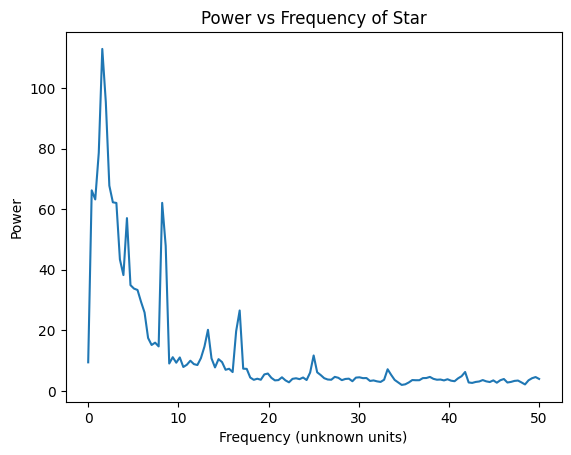

In [29]:
star1 = flux.iloc[0, 1:]

### find fs argument (frequency of sampling)
freqs, psd = welch(star1, fs=100)

plt.plot(freqs, psd)
plt.title("Power vs Frequency of Star")
plt.xlabel("Frequency (unknown units)")
plt.ylabel("Power")

**One concern: do we want to take max frequency? do a weighted average of the top few?**

In [ ]:
def get_frequency(flux, fs):
    """
    Find the frequency of a planet's orbit by using signal.welch to calculate the frequency at 
    which the planet passes in front of the star, causing the flux (as measured from the kepler 
    telescope) to decrease

    Parameters
    ---------
    flux: np.array or pd.Series
        measured brightness of a star at different time points
    fs: float
        sampling frequency at which flux measurements were taken in Hz

    Returns
    ---------
    frequency: float
        the frequency of a planet's orbit in Hz
    power: float
        the percentage of all power contained in frequency
    """
    # Get frequencies and corresponding powers
    freqs, psd = welch(flux, fs=fs)

    # Find the frequency with the most power
    highest = np.argmax(psd)
    power = psd[highest] / np.sum(psd)
    frequency = freqs[highest]

    return frequency, power


In [30]:
def compute_radius(frequency, mass):
    """
    Computer the radius of a planet's orbit based on its frequency

    Parameters
    ---------
    frequency: float
        the frequency of a planet's orbit in Hz
    mass: float
        the mass of the orbited star in solar mass (1.988416 x 10^30 kg)

    Returns
    ---------
    radius: float
        the radius of a planet's orbit in kilometers
    """
    # Get gravitational constant, mass in kg, and compute radius
    G_const = 6.6743 * 10**(-11)
    M = mass * 1.988416 * 10**30
    radius = np.cbrt(G_const * M / (4 * np.pi**2 * frequency**2))

    # Convert from meters to kilometers
    radius = radius / 1000

    return radius